In [1]:
import os
import sys
import chardet
import torch
import torch.nn as nn
from torch.nn import functional as F
from collections import Counter, defaultdict
import math
import matplotlib.pyplot as plt
import numpy as np

HYPERPARAMETERS

In [2]:
DATA_FILENAME = "cleaned_data.txt"  
KAGGLE_INPUT_DIR = "/kaggle/input/cleaned-data"
KAGGLE_WORKING_DIR = "/kaggle/working"

batch_size = 8          # baseline, will be bumped if GPU available
context_length = 256
block_size = context_length
max_iters = 7000
eval_interval = 500
learning_rate = 0.0003
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 256
n_head = 4
n_layer = 4
dropout = 0.2

torch.manual_seed(1337)

print(f"Using device: {device}")
if device == 'cuda':
    batch_size = 64

Using device: cuda


DATA FILE PATH HANDLING

In [3]:
data_path = None
if os.path.exists(os.path.join(KAGGLE_WORKING_DIR, DATA_FILENAME)):
    # user uploaded file to working dir
    data_path = os.path.join(KAGGLE_WORKING_DIR, DATA_FILENAME)
else:
    # try to find the file inside any dataset folder in /kaggle/input
    if os.path.exists(KAGGLE_INPUT_DIR):
        for root, dirs, files in os.walk(KAGGLE_INPUT_DIR):
            if DATA_FILENAME in files:
                data_path = os.path.join(root, DATA_FILENAME)
                break

# fallback to local path if present
if data_path is None and os.path.exists(DATA_FILENAME):
    data_path = DATA_FILENAME

if data_path is None:
    raise FileNotFoundError(f"{DATA_FILENAME} not found. Place it in /kaggle/input/<dataset>/ or upload to working dir.")

print('Loading file from:', data_path)

Loading file from: /kaggle/input/cleaned-data/cleaned_data.txt


DATA LOADING

In [4]:
with open(data_path, 'rb') as f:
    raw = f.read(1024 * 1024)  # read up to first MB
    detected = chardet.detect(raw)
    enc = detected.get('encoding', 'utf-8')
    print('Detected encoding:', detected)

# Read full file using detected encoding, but ignore errors to be robust
with open(data_path, 'r', encoding=enc or 'utf-8', errors='ignore') as f:
    text = f.read()

print('✅ File loaded — length:', len(text))


Detected encoding: {'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}
✅ File loaded — length: 15953988


BPE - TOKENIZER

In [5]:
import os
import pickle

tokenizer_file = '/kaggle/input/bpe-tokenizer/bpe_tokenizer.pkl'

if os.path.exists(tokenizer_file):
    with open(tokenizer_file, 'rb') as f:
        tokenizer_data = pickle.load(f)
    stoi = tokenizer_data['stoi']
    itos = tokenizer_data['itos']
    vocab_size = tokenizer_data['vocab_size']
    print(f"Loaded tokenizer with {vocab_size} tokens")
else:
    raise FileNotFoundError(f"Tokenizer file '{tokenizer_file}' not found. "
                           "Please ensure the tokenizer file is available in Kaggle input.")

print(f"BPE vocab size: {vocab_size}")

def encode_text(text):
    """Encode text using the loaded BPE tokenizer."""
    tokens = []
    for word in text.split():
        w = '▁' + ' '.join(list(word)) + ' </w>'
        i = 0
        while i < len(w):
            for j in range(len(w), i, -1):
                piece = w[i:j]
                if piece in stoi:
                    tokens.append(stoi[piece])
                    i = j
                    break
            else:
                i += 1
    return tokens

def decode_tokens(token_ids):
    """Decode token IDs back to text using the loaded BPE tokenizer."""
    text = ''.join([itos[i] for i in token_ids])
    text = text.replace('▁', ' ').replace('</w>', '')
    return text

Loaded tokenizer with 2943 tokens
BPE vocab size: 2943


PREPARING DATASET

In [6]:
data = torch.tensor(encode_text(text), dtype=torch.long)
train_n = int(0.9 * len(data))
train_data = data[:train_n]
val_data = data[train_n:]
print('Train tokens:', len(train_data), 'Val tokens:', len(val_data))

def get_batch(split='train'):
    source = train_data if split == 'train' else val_data
    max_start = len(source) - context_length - 1
    if max_start <= 0:
        raise ValueError('Dataset too small for the chosen context_length')
    ix = torch.randint(max_start, (batch_size,))
    x = torch.stack([source[i:i + context_length] for i in ix])
    y = torch.stack([source[i + 1:i + context_length + 1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss_and_perplexity(model):
    model.eval()
    out = {}
    perplexities = {}
    
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        
        # Calculate average loss and perplexity
        avg_loss = losses.mean().item()
        out[split] = avg_loss
        perplexities[split] = math.exp(avg_loss)
    
    model.train()
    return out, perplexities

Train tokens: 14097627 Val tokens: 1566403


MULTI-HEAD SELF ATTENTION

In [7]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

FFNN

In [8]:
class FeedFoward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x




LANGUAGE MODELLING-BIGRAM MODEL

In [9]:
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(context_length, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B2, T2, C = logits.shape
            logits = logits.view(B2 * T2, C)
            targets = targets.view(B2 * T2)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -context_length:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


model = BigramLanguageModel()
model = model.to(device)
print('Model parameters:', sum(p.numel() for p in model.parameters()))


Model parameters: 4731775


TRAINING

Starting training...
step 0: train loss 8.0305, val loss 8.0296
         train perplexity 3073.26, val perplexity 3070.67
step 500: train loss 2.1193, val loss 2.1473
         train perplexity 8.33, val perplexity 8.56
step 1000: train loss 1.7658, val loss 1.8080
         train perplexity 5.85, val perplexity 6.10
step 1500: train loss 1.6519, val loss 1.6947
         train perplexity 5.22, val perplexity 5.44
step 2000: train loss 1.5832, val loss 1.6340
         train perplexity 4.87, val perplexity 5.12
step 2500: train loss 1.5388, val loss 1.5966
         train perplexity 4.66, val perplexity 4.94
step 3000: train loss 1.5108, val loss 1.5708
         train perplexity 4.53, val perplexity 4.81
step 3500: train loss 1.4934, val loss 1.5511
         train perplexity 4.45, val perplexity 4.72
step 4000: train loss 1.4626, val loss 1.5186
         train perplexity 4.32, val perplexity 4.57
step 4500: train loss 1.4438, val loss 1.5074
         train perplexity 4.24, val perplexity 4.

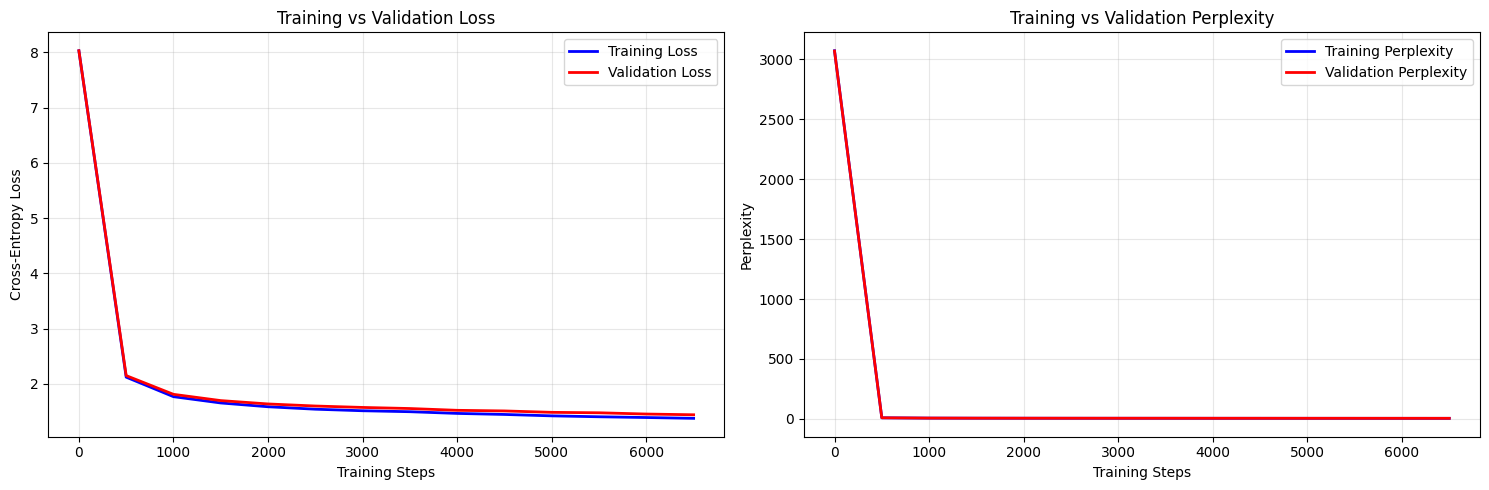

Plots saved to: /kaggle/working/training_metrics.png


In [10]:
# ----------------------------
# Training loop with plotting
# ----------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Lists to store metrics for plotting
train_losses = []
val_losses = []
train_perplexities = []
val_perplexities = []
steps = []

print("Starting training...")
for it in range(max_iters):
    if it % eval_interval == 0:
        losses, perplexities = estimate_loss_and_perplexity(model)
        
        # Store metrics for plotting
        steps.append(it)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        train_perplexities.append(perplexities['train'])
        val_perplexities.append(perplexities['val'])
        
        print(f"step {it}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"         train perplexity {perplexities['train']:.2f}, val perplexity {perplexities['val']:.2f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print("\nGenerating plots...")

# Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training and Validation Loss
ax1.plot(steps, train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(steps, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Training and Validation Perplexity
ax2.plot(steps, train_perplexities, 'b-', label='Training Perplexity', linewidth=2)
ax2.plot(steps, val_perplexities, 'r-', label='Validation Perplexity', linewidth=2)
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Perplexity')
ax2.set_title('Training vs Validation Perplexity')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(KAGGLE_WORKING_DIR, 'training_metrics.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plots saved to: {plot_path}")



EVALUATION

In [11]:
print("\nFinal Evaluation:")
final_losses, final_perplexities = estimate_loss_and_perplexity(model)
print(f"Final Training Loss: {final_losses['train']:.4f}")
print(f"Final Validation Loss: {final_losses['val']:.4f}")
print(f"Final Training Perplexity: {final_perplexities['train']:.2f}")
print(f"Final Validation Perplexity: {final_perplexities['val']:.2f}")

os.makedirs(KAGGLE_WORKING_DIR, exist_ok=True)
model_path = os.path.join(KAGGLE_WORKING_DIR, 'bigram_model.pt')
torch.save(model.state_dict(), model_path)
print('Saved model to', model_path)

print('\n--- Generated text (decoded) ---')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
out_ids = model.generate(context, max_new_tokens=500)[0].tolist()
print(decode_tokens(out_ids))


metrics_data = {
    'steps': steps,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_perplexities': train_perplexities,
    'val_perplexities': val_perplexities
}

metrics_path = os.path.join(KAGGLE_WORKING_DIR, 'training_metrics.pkl')
import pickle
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics_data, f)
print(f"Metrics data saved to: {metrics_path}")


Final Evaluation:
Final Training Loss: 1.3689
Final Validation Loss: 1.4348
Final Training Perplexity: 3.93
Final Validation Perplexity: 4.20
Saved model to /kaggle/working/bigram_model.pt

--- Generated text (decoded) ---
!स के लिए मुसलमान भी है, परछंटन आवश्यक होने में वह एक छात्रक में सैनिक कथा से जुड़े हैं। लेकिन देश के तुलना में मरुस्थ के संबंधक प्रेम को कारण तोस्वेज 25 देखकर आती है। यह संबंधित उन्देला के देशक से बदल देते है। इस्लाम, चिट्ठ आयोचकों को प्रयोक्ताष्ट्रण दिशा में ही वानस्पति से केंद्र को आत्मविद्याया और ही सैन्य से ही बोलते। इन चिकित्सामूरों के एटैंट की खोज भी बांध करते हुए मांस पतावों के करण एक अधिक शक्तिगृह या तेज चिरसो, डालाकार का प्रयोग होता है पूटा चोप और वे तेज़ के वातकाला 52% नियंत्रण जन अधिग
Metrics data saved to: /kaggle/working/training_metrics.pkl
